# Visualisation 

Use the following functions to load the data for a particular function and visualise in 2D. Use the PCA function below for high dimensional functions to reduce dimensions to 2D and visualise them.

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
from IPython.display import clear_output
import ast
import re

In [29]:
# Load specific function number initial provided data by using the following method 

def read_initial_inputs(function_no):
    """
    Load the input data of the initial provided data for a particular function.
    """
    return np.load('initial_data/function_'+str(function_no)+'/initial_inputs.npy')

def read_initial_outputs(function_no):
    """
    Load the output data of the initial provided data for a particular function.
    """
    return np.load('initial_data/function_'+str(function_no)+'/initial_outputs.npy')

In [30]:
def read_input_from_evaluation_weeks(function_no):
    """
    Load the weekly input evaluation data for a particular function.
    """
    inputs_from_all_weeks = []
    with open("weekly_input_output/week_7/inputs.txt", "r") as f:
        content = f.read()

   # Remove numpy array wrappers
    content = re.sub(r'array\((.*?)\)', r'\1', content, flags=re.DOTALL)

    # Extract each top-level list block
    blocks = re.findall(r'\[[\s\S]*?\](?=\n|\Z)', content)

    data = [ast.literal_eval(block) for block in blocks]

    # Convert inner lists back to numpy arrays
    # data = [[np.array(inner) for inner in block] for block in data]

    # Go through the list of lists and select f_1
    for week in range(0,len(data)):
        inputs_from_all_weeks.append(data[week][int(function_no)-1])

    print(inputs_from_all_weeks)
    
    return inputs_from_all_weeks 

In [31]:
def read_output_from_evaluation_weeks(function_no):
    """
    Load the weekly output evaluation data for a particular function.
    """
    outputs_from_all_weeks = []
    with open("weekly_input_output/week_7/outputs.txt", "r") as f:
        content = f.read()
    
    # Remove np.float64(...) wrapper
    content = re.sub(r'np\.float64\((.*?)\)', r'\1', content, flags=re.DOTALL)

    # Extract each list block
    blocks = re.findall(r'\[[\s\S]*?\](?=\n|\Z)', content)

    # Convert each block into Python list
    data = [ast.literal_eval(block) for block in blocks]

    # # Convert into numpy arrays (optional but recommended)
    # data = [np.array(block) for block in data]
    
    # Go through the list of lists and select f_1
    for week in range(0,len(data)):
        outputs_from_all_weeks.append(data[week][int(function_no)-1])

    print(outputs_from_all_weeks)
    
    return outputs_from_all_weeks 

# f_1_week_outputs = read_output_from_weeks(1)

In [32]:
# Read the initial data points provided for the BBO project
inputs = read_initial_inputs(1)
# print(inputs)

outputs = read_initial_outputs(1)
# print(outputs)

In [33]:
f_1_week_inputs = read_input_from_evaluation_weeks(1)
f_1_week_outputs = read_output_from_evaluation_weeks(1)

[[0.223696, 0.166025], [0.971666, 0.994621], [0.5808, 0.403103], [0.530137, 0.504108], [0.2841, 0.7542], [0.879672, 0.190177], [0.047162, 0.569522]]
[1.2121776220527492e-74, -4.515332508840043e-176, 9.827384409509805e-19, 3.9242133027962733e-14, 4.690604757883212e-91, -1.8323318855977174e-178, -1.80712027198355e-113]


In [34]:
f_1_week_inputs = np.array(f_1_week_inputs)
f_1_week_outputs = np.array(f_1_week_outputs)

outputs = outputs.reshape(-1, 1)
f_1_week_outputs = f_1_week_outputs.reshape(-1, 1)


inputs = np.vstack((inputs, f_1_week_inputs))
outputs = np.vstack((outputs, f_1_week_outputs))

outputs = outputs.flatten()


# print(outputs)

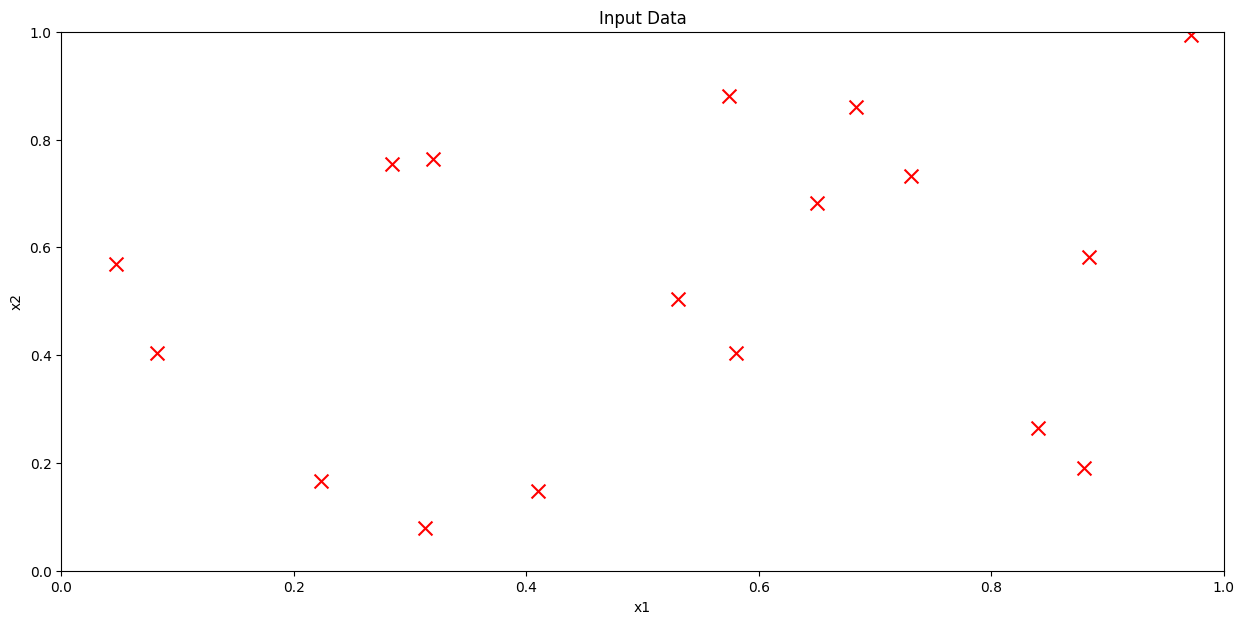

In [35]:
# Plot the initial data
X1 = inputs.copy()[:, 0]
X2 = inputs.copy()[:, 1]
Y = outputs.copy()

#Initialise plots
fig, ax = plt.subplots(figsize=(15, 7))
#Set the x and y limits, labels and dynamic title
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_ylabel('x2')
ax.set_xlabel('x1')
ax.set_title('Input Data')
#Plot queries
ax.scatter(X1, X2, c='r', marker='x', s=100)
plt.show()

3.9242133027962733e-14


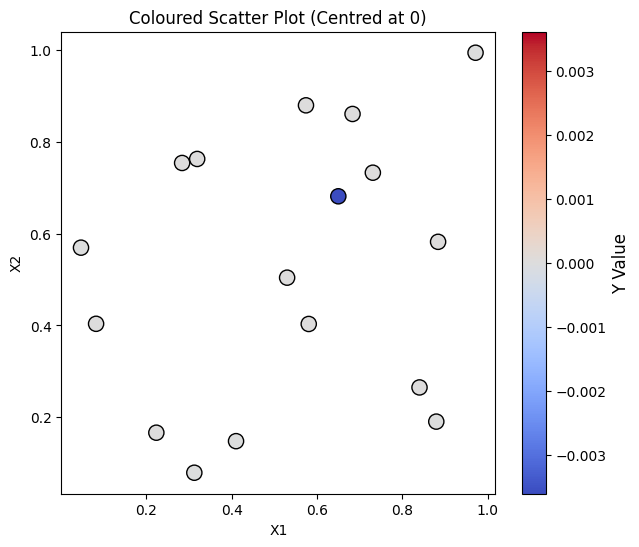

In [37]:
# Heatmap with the corresponding output data
df = pd.DataFrame({'x1': X1, 'x2':X2, 'y': Y})
df['y'] = df['y'].astype(float)

print(df['y'].max())

import matplotlib.pyplot as plt
import matplotlib.colors as colors


max_abs = max(abs(df['y'].min()), abs(df['y'].max()))

# Normalise around 0
norm = colors.TwoSlopeNorm(
    vmin=-max_abs,
    vcenter=0,
    vmax=max_abs
)


plt.figure(figsize=(7,6))

sc = plt.scatter(
    df['x1'],
    df['x2'],
    c=df['y'],
    cmap='coolwarm',
    norm=norm,
    s=120,
   edgecolor='black'
)

# Add colorbar (this is the colour legend)
cbar = plt.colorbar(sc)
cbar.set_label('Y Value', fontsize=12)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Coloured Scatter Plot (Centred at 0)')

plt.show()